# Phase-augmented ergodic control: a 2-DoF key-in-lock toy

One ergodic controller for a sequential task, insert the key and then turn it, with
exploration that emerges when the robot is stuck and no per-step success detector.

- The robot controls the pose $s = (x, \theta)$: insertion depth and rotation.
- The phase $\varphi \in [0, 1]$ is an extra dimension that is **not controlled**. It is a gated clock,
  estimated by projecting $s$ onto the master trajectory, never a decision variable of the controller.
- Each step the **target density** is the exploration cloud weighted by an asymmetric kernel
  around $\varphi + \text{lead}$ and normalised, i.e. $q(s \mid \varphi)$, not the joint.
- The **spatial statistic** stores $(s, \varphi)$ pairs weighted by phase similarity, so
  memory from other phases fades without an explicit decay.
- A stall freezes $\varphi$, the statistic covers that slice, and the robot is pushed to explore.
  The backward kernel width $\sigma_b$ grows with the stall, re-activating earlier-phase targets.

The control law is the E2T2 law of `Ergodic_Exploration_using_TT_python310.ipynb`, unchanged. What
changes is what it is fed (marked **CHANGE** below). In 2-D the $K^2$ coefficients are plain arrays,
so no TT-cross and no rounding are needed; Section 7 checks the law against the TT `ErgodicController`.
The mean-shift step of the JavaScript prototype is ported as well, only to validate this port
against the prototype (Section 7).

## Overview: one control step, and how it recovers from a fault

The fault is a jam: the key pressed against the face at the wrong angle. Nothing detects it. The recovery
emerges from the phase clock stalling: the dashed arrows are the effects a stall has on the next steps.

```mermaid
flowchart TD
    S["Measured pose s = metric(x, θ)"]

    subgraph CTRL["Ergodic controller"]
        SB["Backward width<br/>σ_b = min(σ_f (1 + stall / T(φ)), 0.5)"]
        TGT["Target density Ŵ(φ)<br/>cloud weighted by a phase kernel around φ + lead:<br/>σ_f ahead, σ_b behind; mass 1"]
        STAT["Spatial statistic W(φ)<br/>memory weighted by phase similarity to φ; mass 1"]
        LAW["E2T2 law<br/>u = −u_max b / ‖b‖,  b_i = Σ_k Λ_k (W_k − Ŵ_k) ∇_i Φ_k(s)"]
        SB --> TGT
        TGT --> LAW
        STAT --> LAW
    end

    subgraph PHASE["Phase clock (not controlled)"]
        PROJ["Project s onto the master<br/>in the window φ − 0.05 … φ + 0.12  →  φ̂"]
        ADV{"φ̂ > φ + σ_f / 4 ?"}
        UP["φ = φ̂  (only ever forward)"]
        STALL["Stall counter:<br/>reset when φ passes the last progress mark + σ_f, else + 1"]
        PROJ --> ADV
        ADV -- yes --> UP
        ADV -- no --> STALL
        UP --> STALL
    end

    S --> SB
    S --> STAT
    LAW --> MOVE["Robot moves: s + u through the lock physics<br/>(a jam clamps x at the face and freezes θ)"]
    MOVE --> PROJ
    STALL --> MEM["Store (s, φ) in memory every 3rd step"]
    MEM --> S

    STALL -.->|"stall grows:<br/>σ_b widens, earlier-phase targets return"| SB
    MEM -.->|"a frozen φ fills its slice:<br/>W matches Ŵ there, so the law moves on"| STAT
```

In a jam the chain runs as follows:
1. The robot presses on the face, so $\hat\varphi$ stops advancing and $\varphi$ freezes.
2. The stall counter grows, and the spatial statistic fills the frozen slice until it matches the target there. The law then
   sends the robot to the parts of the target it has not covered yet.
3. $\sigma_b$ widens with the stall, so the target takes in earlier phases: backing off and other angles.
4. On the next approach, at a different $\theta$, the key can enter the keyway, $\hat\varphi$ advances, and the stall resets.

In [50]:
import math
import time
from dataclasses import dataclass

import numpy as np
from IPython.display import HTML, display
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

# The module beside this notebook; the kernel runs in this directory.
from ergodic_controller import ErgodicController

## 1. The E2T2 pieces, unchanged

Basis $\phi_k(z) = \cos(\pi k z / L)$ on $[0, L]$ with $L = 1$, its derivative, the weights
$\Lambda_{\mathbf k} = (1 + \|\mathbf k\|^2)^{-(d+1)/2}$, and `pull2centre`, exactly as in the E2T2
notebook. The control law is

$$b_i = \sum_{\mathbf k} \Lambda_{\mathbf k} \big(\mathcal W_{\mathbf k} - \hat{\mathcal W}_{\mathbf k}\big)\, \nabla_i \Phi_{\mathbf k}(z), \qquad u = -u_{\max} \frac{b}{\|b\|}.$$

With $d = 2$ the gradient sums are two matrix products, $b_x = \phi'(z_x)^\top (\Lambda \circ D)\, \phi(z_\theta)$
and $b_\theta = \phi(z_x)^\top (\Lambda \circ D)\, \phi'(z_\theta)$, with $D = \mathcal W - \hat{\mathcal W}$.

In [51]:
def basis(z, K):  # (M,) -> (M, K)
    return np.cos(np.pi * np.outer(z, np.arange(K)))


def basis_derivative(z, K):  # (M,) -> (M, K)
    k = np.arange(K)
    return -np.pi * k * np.sin(np.pi * np.outer(z, k))


def optimisation_weights(K, d=2):  # (K, K)
    k = np.arange(K)
    return (1.0 + k[:, None] ** 2 + k[None, :] ** 2) ** (-(d + 1) / 2)


def pull2centre(z, alpha=20.0, c=1.0 / 20):
    weight = np.tanh(alpha * (z - c)) / 2 + np.tanh(alpha * (1 - c - z)) / 2
    dz = -np.tanh(alpha * (z - c)) / 2 + np.tanh(alpha * (1 - c - z)) / 2
    return weight, dz


def ergodic_direction(z, D, lam):
    """E2T2's step direction at cube state z (2,), D = W - W_hat (K, K): unit length."""
    K = D.shape[0]
    phi_x, phi_t = basis(z[:1], K)[0], basis(z[1:], K)[0]
    dphi_x, dphi_t = basis_derivative(z[:1], K)[0], basis_derivative(z[1:], K)[0]
    LD = lam * D
    b = np.array([dphi_x @ LD @ phi_t, phi_x @ LD @ dphi_t])
    u = -b / (np.linalg.norm(b) + 1e-10)
    weight, centre = pull2centre(z)
    centre = centre / (np.linalg.norm(centre) + 1e-8)
    u = u * weight + centre * (1 - weight)
    return u / (np.linalg.norm(u) + 1e-8)


# Gradient check: phi'(z) against a central difference of phi(z).
_z, _eps = np.array([0.137, 0.71]), 1e-6
_fd = (basis(_z + _eps, 12) - basis(_z - _eps, 12)) / (2 * _eps)
print("max |dphi - finite difference|:", np.abs(basis_derivative(_z, 12) - _fd).max())
assert np.allclose(basis_derivative(_z, 12), _fd, atol=1e-6)

max |dphi - finite difference|: 7.01666635904985e-09


## 2. World, master trajectory and exploration cloud

Units: $x$ in depth units, $\theta$ in degrees. The controller works on the scaled state
$s = \texttt{metric}(x, \theta) = (x, \theta / 10)$, so that both axes are comparable. `metric` is
the one place that defines this; the 6-DoF version replaces it with whitening by the cloud covariance.
The cube of the Fourier basis is $z = (s - s_{lo}) / 19$, the same divisor on both axes, so it keeps the metric isotropic.

Master, in scaled units: $\varphi \in [0, 0.5]$: $(16\varphi, 0)$; $\varphi \in [0.5, 1]$: $(8, 18(\varphi - 0.5))$.

The random numbers come from the prototype's linear congruential generators, so this port draws
the same cloud and the same actuator noise as the JavaScript.

In [52]:
THETA_SCALE = 10.0  # degrees per scaled unit


def metric(x, theta_deg):  # world (x, deg) -> scaled s, (..., 2)
    return np.stack(np.broadcast_arrays(x, np.asarray(theta_deg) / THETA_SCALE), axis=-1)


S_LO = np.array([-1.5, -5.5])  # scaled box of the cube
S_SPAN = 19.0


def to_cube(s):
    return (s - S_LO) / S_SPAN


def lcg(seed, a, c, m):
    """The prototype's generator, in doubles as JavaScript computes it."""
    state = float(seed)

    def draw():
        nonlocal state
        state = (state * a + c) % m
        return state / m

    return draw


def gauss(rnd):
    u = rnd() or 1e-9
    v = rnd()
    return math.sqrt(-2 * math.log(u)) * math.cos(2 * math.pi * v)


def make_cloud():  # (800, 2) scaled
    rnd = lcg(7, 1664525.0, 1013904223.0, 4294967296.0)
    points = []
    for _ in range(500):  # insertion
        p = -0.03 + rnd() * 0.53
        x = 16 * p + gauss(rnd) * 0.3
        points.append((x, min(35.0, max(-35.0, gauss(rnd) * 14))))
    for _ in range(260):  # turning
        x = min(8.25, 8 + gauss(rnd) * 0.15)
        points.append((x, rnd() * 102 + gauss(rnd) * 6))
    for _ in range(40):  # demonstration end states: where phi = 1 is
        x = 8 - abs(gauss(rnd)) * 0.05
        points.append((x, 90 + gauss(rnd) * 1.5))
    points = np.array(points)
    return metric(points[:, 0], points[:, 1])


PHI_GRID = np.linspace(0.0, 1.0, 401)


def master_path(phi):  # (M,) -> (M, 2) scaled
    phi = np.atleast_1d(phi)
    turning = phi >= 0.5
    return np.column_stack(
        [np.where(turning, 8.0, 16 * phi), np.where(turning, 18 * (phi - 0.5), 0.0)]
    )


MASTER = master_path(PHI_GRID)


def project(s, master, lo, hi):
    """Phase of the master sample nearest to s, over the phases in [lo, hi]."""
    phis = PHI_GRID
    d = ((master - s) ** 2).sum(axis=1)
    d[(phis < lo) | (phis > hi)] = np.inf
    return PHI_GRID[np.argmin(d)] if np.isfinite(d).any() else lo


CLOUD = make_cloud()
PHI_CLOUD = PHI_GRID[np.argmin(((CLOUD[:, None, :] - MASTER[None]) ** 2).sum(axis=2), axis=1)]

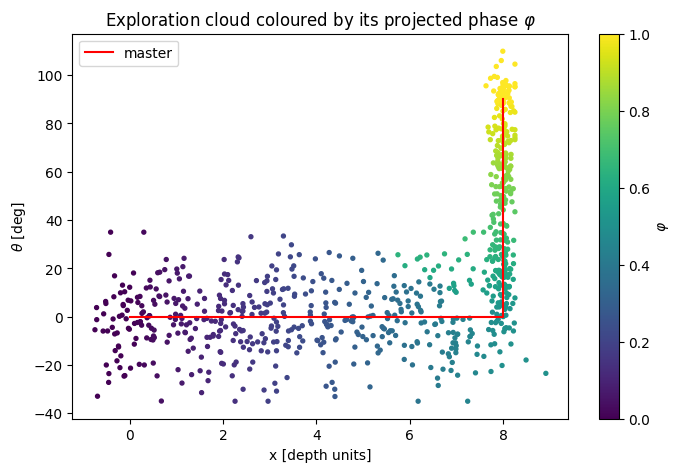

cloud points at the corner (x > 7.5, |theta| < 3 deg) and their phases: [0.5   0.485 0.498 0.485 0.49  0.492 0.492 0.5   0.492 0.503 0.503]


In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
points = ax.scatter(CLOUD[:, 0], CLOUD[:, 1] * THETA_SCALE, c=PHI_CLOUD, s=8, cmap="viridis")
ax.plot(MASTER[:, 0], MASTER[:, 1] * THETA_SCALE, "-r", lw=1.5, label="master")
fig.colorbar(points, ax=ax, label=r"$\varphi$")
ax.set_xlabel("x [depth units]")
ax.set_ylabel(r"$\theta$ [deg]")
ax.set_title(r"Exploration cloud coloured by its projected phase $\varphi$")
ax.legend()
plt.show()
boundary = PHI_CLOUD[(CLOUD[:, 0] > 7.5) & (np.abs(CLOUD[:, 1]) < 0.3)]
print(
    "cloud points at the corner (x > 7.5, |theta| < 3 deg) and their phases:",
    np.round(boundary, 3),
)

## 3. Derived parameters

All data-derived except $\beta$:

- $h$: the median distance to the $k$-th nearest neighbour in the cloud, $k = \mathrm{round}(\sqrt N)$.
- $d\ell/d\varphi$: the master path length per unit $\varphi$.
- $\sigma_f = \sigma_0 = \text{lead} = h / (d\ell/d\varphi)$.
- $T(\varphi) = \beta \sum_j \exp(-(\varphi_j - \varphi)^2 / 2\sigma_f^2)$: the recorded dwell per phase slice.
- $\sigma_b = \min(\sigma_f (1 + \text{stall} / T(\varphi)), 0.5)$ with backward expansion on, else $\sigma_f$.
- $K = 10$ Fourier modes per axis: not derived, the resolution the online 6-DoF controller runs at.

In [54]:
N_CLOUD = len(CLOUD)
_k = round(math.sqrt(N_CLOUD))
_pairwise = np.hypot(*(CLOUD[:, None, :] - CLOUD[None, :, :]).transpose(2, 0, 1))
_pairwise[np.diag_indices(N_CLOUD)] = np.inf
H = np.sort(np.sort(_pairwise, axis=1)[:, _k - 1])[N_CLOUD // 2]
DL_DPHI = np.linalg.norm(np.diff(MASTER, axis=0), axis=1).sum()
SIGMA_F = H / DL_DPHI
K = 10  # what the online 6-DoF controller can afford
LAMBDA = optimisation_weights(K)


def dwell(phi, beta):
    """T(phi): recorded dwell per phase slice, in cloud points, times beta."""
    return beta * np.exp(-((PHI_CLOUD - phi) ** 2) / (2 * SIGMA_F**2)).sum()


print(f"N = {N_CLOUD}, k = {_k}, h = {H:.4f} scaled units")
print(f"dl/dphi = {DL_DPHI:.4f}, sigma_f = sigma_0 = lead = {SIGMA_F:.4f}")
print(f"K = {K} modes per axis ({K * K} coefficients), cube half-wavelength {S_SPAN / (K - 1):.3f}")
print(
    "T(phi) at beta = 1:",
    {p: round(dwell(p, 1.0), 1) for p in (0.0, 0.25, 0.5, 0.75, 1.0)},
)

N = 800, k = 28, h = 0.7501 scaled units
dl/dphi = 17.0000, sigma_f = sigma_0 = lead = 0.0441
K = 10 modes per axis (100 coefficients), cube half-wavelength 2.111
T(phi) at beta = 1: {0.0: np.float64(92.8), 0.25: np.float64(96.5), 0.5: np.float64(68.4), 0.75: np.float64(38.1), 1.0: np.float64(94.2)}


## 4. Lock physics and phase estimator

The lock face is at $x = 3$ with the keyway at angle $\kappa$; entry only if $|\theta - \kappa| < 4°$.
Inside, the keyway holds $\theta = \kappa$ until $x \ge 7.8$; there the key may turn, and while turned
it cannot be pulled out. Pressing on the face at a wrong angle jams: $x$ is clamped to 3 and $\theta$ is
frozen while $x > 2.88$. Success is $\theta \ge \kappa + 89°$ while inside.

In [55]:
FACE, DEPTH = 3.0, 8.0
TURN_DEPTH = DEPTH - 0.2  # the key can turn from here
KEYWAY_TOL = 4.0 / THETA_SCALE
TURNED = 0.5 / THETA_SCALE  # beyond this the key is held in
JAM_RELEASE = FACE - 0.12
SUCCESS_TURN = 89.0 / THETA_SCALE
THETA_LIMITS = (-5.0, 13.0)  # scaled
V_MAX = 0.07  # scaled units per step
NOISE = 0.25  # actuator noise is uniform in +-NOISE/2 per axis


@dataclass
class Lock:
    kt: float  # keyway angle, scaled
    inside: bool = False
    jam: bool = False


def _inside_step(lock, s, nx, nt):
    if s[0] < TURN_DEPTH:
        nt = lock.kt
    else:
        nt = max(lock.kt, nt)
        if nt > lock.kt + TURNED:
            nx = max(nx, TURN_DEPTH)
    nx = min(DEPTH, nx)
    if nx < FACE:
        if nt <= lock.kt + TURNED:
            lock.inside = False
        else:
            nx = FACE + 0.01
    return nx, nt


def _outside_step(lock, s, nx, nt):
    if lock.jam and s[0] > JAM_RELEASE:
        nt = s[1]
    if nx >= FACE:
        if abs(nt - lock.kt) < KEYWAY_TOL:
            lock.inside, lock.jam = True, False
            nt, nx = lock.kt, min(nx, DEPTH)
        else:
            nx, lock.jam = FACE, True
    if lock.jam and nx < JAM_RELEASE:
        lock.jam = False
    return nx, nt


def lock_step(lock, s, s_new):
    """The pose the lock lets the robot reach from s when it commands s_new."""
    step = _inside_step if lock.inside else _outside_step
    nx, nt = step(lock, s, s_new[0], s_new[1])
    return np.array([nx, min(THETA_LIMITS[1], max(THETA_LIMITS[0], nt))])


@dataclass
class Phase:
    phi: float = 0.0
    stall: int = 0
    last_progress: float = 0.0


def advance_phase(phase, s):
    """Monotone phase estimate with hysteresis."""
    phi_hat = project(s, MASTER, max(0.0, phase.phi - 0.05), min(1.0, phase.phi + 0.12))
    if phi_hat > phase.phi + SIGMA_F / 4:
        phase.phi = phi_hat


def update_stall(phase):
    if phase.phi > phase.last_progress + SIGMA_F:
        phase.last_progress, phase.stall = phase.phi, 0
    else:
        phase.stall += 1


# Small tests of the pure functions.
_lock = Lock(kt=metric(0, 14.0)[1])
assert lock_step(_lock, np.array([2.95, 0.0]), np.array([3.02, 0.0]))[0] == FACE and _lock.jam
assert (
    lock_step(_lock, np.array([2.95, 0.0]), np.array([2.97, 0.5]))[1] == 0.0
)  # jammed: theta frozen
_lock = Lock(kt=1.4)
assert lock_step(_lock, np.array([2.95, 1.4]), np.array([3.02, 1.5]))[1] == 1.4 and _lock.inside
_lock = Lock(kt=1.4, inside=True)
assert (
    lock_step(_lock, np.array([7.9, 3.0]), np.array([7.0, 3.0]))[0] == TURN_DEPTH
)  # turned: held in
_phase = Phase()
advance_phase(_phase, master_path(0.1)[0])
assert math.isclose(_phase.phi, 0.1)
print("physics and phase tests passed")

physics and phase tests passed


## 5. Controller

**CHANGE** with respect to E2T2: what the law is fed. Both are recomputed from the phase, not accumulated once.

- Target density, phase-conditioned and normalised per step:
  $\hat{\mathcal W}_{\mathbf k}(\varphi) = \sum_j w_j \Phi_{\mathbf k}(z_j)$ with
  $w_j \propto \exp(-d_j^2 / 2\sigma^2)$, $d_j = \varphi_j - \min(1, \varphi + \text{lead})$, $\sigma = \sigma_f$ if $d_j > 0$ else $\sigma_b$.
- Spatial statistic, phase-weighted and normalised to mass 1 as in E2T2:
  $\mathcal W_{\mathbf k}(\varphi) = \sum_m v_m \Phi_{\mathbf k}(z_m) / \sum_m v_m$ with
  $v_m = \exp(-(\varphi_m - \varphi)^2 / 2\sigma_f^2) \cdot \Delta t_m$.

There is no $\alpha$: the difference $\mathcal W - \hat{\mathcal W}$ does what the prototype's
coverage discount $\exp(-c)$ did. $\mathcal W$ and $\hat{\mathcal W}$ both have mass 1, as in E2T2, so the law matches
shapes and is never dominated by how long the slice has been occupied (Section 7.5 shows what happened with
$\mathcal W$ divided by $T(\varphi)$ instead: its mass grew with the stall and the law turned away from the target).
$T(\varphi)$ still sets the stall scale of $\sigma_b$.
With $\varphi$ frozen, $v_m = \Delta t_m$ and $\mathcal W$ is exactly E2T2's time average, so the law is the original one (checked in Section 7).

$\hat{\mathcal W} = \phi(x)^\top \operatorname{diag}(w)\, \phi(\theta)$ is one $(K \times N)(N \times K)$ product
per step. $\mathcal W$ is rebuilt only when $\varphi$ changes and grows incrementally otherwise.
Memory is stored every third step with $\Delta t = 3$, and samples with $v_m / T < 10^{-4}$ are skipped, as in the prototype.

In [56]:
MEMORY_EVERY = 3
SKIP_WEIGHT = 1e-4


def target_weights(phi, sigma_b):
    d = PHI_CLOUD - min(1.0, phi + SIGMA_F)
    sigma = np.where(d > 0, SIGMA_F, sigma_b)
    w = np.exp(-(d**2) / (2 * sigma**2))
    return w / w.sum()


def memory_weights(memory, start, phi, T):
    """v_m / T(phi) of the memory rows from start on, and their indices."""
    rows = np.asarray(memory[start:]).reshape(-1, 4)
    v = np.exp(-((rows[:, 2] - phi) ** 2) / (2 * SIGMA_F**2)) * rows[:, 3] / T
    keep = v >= SKIP_WEIGHT
    return v[keep], rows[keep, :2]


class ErgodicPhaseController:
    """The E2T2 law, fed the phase-conditioned target density and spatial statistic."""

    def __init__(self):
        self.W, self.W_sum, self.mass = np.zeros((K, K)), np.zeros((K, K)), 0.0
        self.W_hat = np.zeros((K, K))
        self.phi, self.n_added = None, 0
        z = to_cube(CLOUD)
        self.cloud_basis = basis(z[:, 0], K), basis(z[:, 1], K)

    def sync(self, phi, T, memory):
        if phi != self.phi:
            self.phi, self.n_added, self.W_sum, self.mass = phi, 0, np.zeros((K, K)), 0.0
        v, s = memory_weights(memory, self.n_added, phi, T)
        z = to_cube(s)
        self.W_sum += (basis(z[:, 0], K) * v[:, None]).T @ basis(z[:, 1], K)
        self.mass += v.sum()
        self.n_added = len(memory)
        # Mass 1 as in E2T2. Before any memory counts for this phase the statistic is
        # empty and the law follows the target alone.
        self.W = self.W_sum / self.mass if self.mass > 0 else np.zeros((K, K))

    def velocity(self, w, s):
        phi_x, phi_t = self.cloud_basis
        self.W_hat = (phi_x * w[:, None]).T @ phi_t
        return V_MAX * ergodic_direction(to_cube(s), self.W - self.W_hat, LAMBDA)

    def density(self, grid_x, grid_t):
        """The spatial statistic as a density on a scaled grid (inverse cosine series)."""
        h = np.where(np.arange(K) == 0, 1.0, 0.5)
        zx, zt = (grid_x - S_LO[0]) / S_SPAN, (grid_t - S_LO[1]) / S_SPAN
        return (basis(zx, K) / h) @ self.W @ (basis(zt, K) / h).T


class MeanShiftController:
    """The prototype's stand-in: mean shift on the coverage-discounted target, statistic on a grid."""

    CELL, NX, NT = 0.25, 48, 76

    def __init__(self):
        r = math.ceil(2.5 * H / self.CELL)
        a = np.arange(-r, r + 1)
        self.r = r
        self.stamp = np.exp(-((a[:, None] ** 2 + a[None, :] ** 2) * self.CELL**2) / (2 * H**2))
        self.grid = np.zeros((self.NX, self.NT))
        self.phi, self.n_added = None, 0

    def _index(self, s):  # Math.round: halves round up
        return np.floor((s - S_LO) / self.CELL + 0.5).astype(int)

    def sync(self, phi, T, memory):
        if phi != self.phi:
            self.phi, self.n_added = phi, 0
            self.grid[:] = 0.0
        v, s = memory_weights(memory, self.n_added, phi, T)
        for v_m, (i, j) in zip(v, self._index(s), strict=True):
            i0, j0 = max(i - self.r, 0), max(j - self.r, 0)
            i1, j1 = min(i + self.r + 1, self.NX), min(j + self.r + 1, self.NT)
            if i0 < i1 and j0 < j1:
                self.grid[i0:i1, j0:j1] += (
                    v_m
                    * self.stamp[
                        i0 - i + self.r : i1 - i + self.r,
                        j0 - j + self.r : j1 - j + self.r,
                    ]
                )
        self.n_added = len(memory)

    def velocity(self, w, s):
        active = w >= 1e-6
        p = CLOUD[active]
        ij = self._index(p)
        valid = (ij >= 0).all(axis=1) & (ij[:, 0] < self.NX) & (ij[:, 1] < self.NT)
        c = np.zeros(len(p))
        c[valid] = self.grid[ij[valid, 0], ij[valid, 1]]
        kk = w[active] * np.exp(-c) * (np.exp(-((p - s) ** 2).sum(axis=1) / (2 * H**2)) + 0.01)
        return kk @ p / kk.sum() - s

In [57]:
STEPS = 5000


class Run:
    """One episode: the robot, the lock, the phase clock and a controller."""

    def __init__(self, kappa, beta=1.0, seed=3, expand=True, controller=ErgodicPhaseController):
        self.lock = Lock(kt=float(metric(0.0, kappa)[1]))
        self.beta, self.expand, self.controller = beta, expand, controller()
        self.noise = lcg(seed, 1103515245.0, 12345.0, 2147483648.0)
        self.s, self.phase = np.array([-0.6, 0.0]), Phase()
        self.memory, self.events, self.log, self.frames = [], [], [], []
        self.n, self.done, self._T = 0, False, (None, None)

    def dwell(self):
        if self._T[0] != self.phase.phi:
            self._T = (self.phase.phi, dwell(self.phase.phi, self.beta))
        return self._T[1]

    def command(self, T):
        phase = self.phase
        sigma_b = min(SIGMA_F * (1 + phase.stall / T), 0.5) if self.expand else SIGMA_F
        self.controller.sync(phase.phi, T, self.memory)
        w = target_weights(phase.phi, sigma_b)
        u = self.controller.velocity(w, self.s)
        u = u + (np.array([self.noise(), self.noise()]) - 0.5) * NOISE
        speed = np.hypot(*u)
        return (u * V_MAX / speed if speed > V_MAX else u), sigma_b, w

    def event(self, text):
        self.events.append(
            (
                self.n,
                f"{text} at step {self.n}: x = {self.s[0]:.2f}, theta = {self.s[1] * THETA_SCALE:.1f} deg, phi = {self.phase.phi:.3f}",
            )
        )

    def step(self, frame_every=0):
        T = self.dwell()
        u, sigma_b, w = self.command(T)
        jammed, inside = self.lock.jam, self.lock.inside
        self.s = lock_step(self.lock, self.s, self.s + u)
        if self.lock.jam and not jammed and not any("jam" in e for _, e in self.events):
            self.event("first jam")
        if self.lock.inside and not inside:
            self.event("keyway found")
        advance_phase(self.phase, self.s)
        update_stall(self.phase)
        if self.n % MEMORY_EVERY == 0:
            self.memory.append((*self.s, self.phase.phi, float(MEMORY_EVERY)))
        turned = (self.s[1] - self.lock.kt) * THETA_SCALE if self.lock.inside else 0.0
        self.log.append((*self.s, self.phase.phi, sigma_b, self.phase.stall / T, turned))
        if frame_every and self.n % frame_every == 0:
            self.frames.append(self.snapshot(w))
        self.n += 1
        if self.lock.inside and self.s[1] >= self.lock.kt + SUCCESS_TURN:
            self.done = True
            self.event("unlocked")

    def snapshot(self, w):
        return {"n": self.n, "w": w, "W": self.controller.W.copy()}

    def run(self, frame_every=0):
        while not self.done and self.n < STEPS:
            self.step(frame_every)
        return self


KAPPAS = [-20, -14, -8, 0, 8, 14, 20]


def sweep(kappas, seeds, **kwargs):
    """{(kappa, seed): (done, steps)} over every combination."""
    return {
        (k, s): (r.done, r.n)
        for k in kappas
        for s in seeds
        for r in [Run(k, seed=s, **kwargs).run()]
    }

## 6. Two runs at $\kappa = 14°$, $\beta = 1$: a happy and a bad flow

The same lock and parameters with two noise seeds: seed 4 unlocks, seed 3 does not.

Left: the world in $(x, \theta)$, with
- the cloud (grey) and the active targets coloured by their weight $w_j$,
- the spatial statistic as a density (blue),
- the master (red), the trail (black),
- the lock face, the keyway at $\kappa \pm 4°$, and the 90° stop.

Right: $\varphi$, $\sigma_b$, stall$/T(\varphi)$ and the turned angle, with the current step marked.

In [58]:
def simulate(kappa, seed):
    """One run with animation frames, its timing and its event log printed."""
    t0 = time.time()
    run = Run(kappa, seed=seed).run(frame_every=100)
    print(f"{run.n} steps in {time.time() - t0:.2f} s, unlocked = {run.done}\n")
    for _, text in run.events:
        print(text)
    return run

In [59]:
GRID_X = np.linspace(S_LO[0], S_LO[0] + 12, 97)
GRID_T = np.linspace(S_LO[1], S_LO[1] + S_SPAN, 153)


def draw_lock(ax, kappa):
    lo, hi = kappa - 4, kappa + 4
    ax.plot([FACE, FACE], [-55, lo], "-k", lw=2)
    ax.plot([FACE, FACE], [hi, 135], "-k", lw=2)
    ax.plot([FACE, DEPTH], [lo, lo], "-", color="0.4", lw=0.8)
    ax.plot([FACE, DEPTH], [hi, hi], "-", color="0.4", lw=0.8)
    ax.plot([TURN_DEPTH, DEPTH], [kappa + 90, kappa + 90], "-g", lw=2, label="90 deg stop")


def draw_world(ax, frame, kappa, log):
    ax.clear()
    controller = ErgodicPhaseController()
    controller.W = frame["W"]
    density = controller.density(GRID_X, GRID_T)
    ax.contourf(GRID_X, GRID_T * THETA_SCALE, density.T, levels=12, cmap="Blues", alpha=0.6)
    ax.scatter(CLOUD[:, 0], CLOUD[:, 1] * THETA_SCALE, s=3, c="0.75")
    points, w = CLOUD, frame["w"]
    active = w > 1e-3 * w.max()
    ax.scatter(
        points[active, 0],
        points[active, 1] * THETA_SCALE,
        s=10,
        c=w[active],
        cmap="autumn_r",
    )
    ax.plot(MASTER[:, 0], MASTER[:, 1] * THETA_SCALE, "-r", lw=1)
    trail = log[: frame["n"] + 1]
    ax.plot(trail[:, 0], trail[:, 1] * THETA_SCALE, "-k", lw=0.4)
    ax.plot(*trail[-1, :1], trail[-1, 1] * THETA_SCALE, "ok", ms=5)
    draw_lock(ax, kappa)
    ax.set_xlim(GRID_X[0], GRID_X[-1])
    ax.set_ylim(-55, 135)
    ax.set_xlabel("x [depth units]")
    ax.set_ylabel(r"$\theta$ [deg]")
    ax.set_title(f"step {frame['n']}")


SERIES = [r"$\varphi$", r"$\sigma_b$", r"stall$/T(\varphi)$", "turned [deg]"]


def animate_run(run, kappa):
    fig = plt.figure(figsize=(12, 5.5), dpi=60, layout="constrained")
    grid = fig.add_gridspec(4, 2, width_ratios=[1.6, 1])
    world = fig.add_subplot(grid[:, 0])
    log = np.array(run.log)
    cursors = []
    for i, label in enumerate(SERIES):
        ax = fig.add_subplot(grid[i, 1])
        ax.plot(log[:, 2 + i], lw=0.8)
        ax.set_ylabel(label)
        cursors.append(ax.axvline(0, color="r", lw=0.8))
    ax.set_xlabel("step")

    def update(frame):
        draw_world(world, frame, kappa, log)
        for cursor in cursors:
            cursor.set_xdata([frame["n"]])

    anim = FuncAnimation(fig, update, frames=run.frames, interval=120)
    plt.close(fig)
    return anim


plt.rcParams["animation.embed_limit"] = 50

### 6.1 Happy flow: seed 4

In [60]:
happy = simulate(14.0, seed=4)
display(HTML(animate_run(happy, 14.0).to_jshtml()))

3254 steps in 0.31 s, unlocked = True

first jam at step 116: x = 3.00, theta = -4.7 deg, phi = 0.182
keyway found at step 1765: x = 3.02, theta = 14.0 deg, phi = 0.182
unlocked at step 3254: x = 8.00, theta = 103.2 deg, phi = 0.993


### 6.2 Bad flow: seed 3

In [61]:
bad = simulate(14.0, seed=3)
display(HTML(animate_run(bad, 14.0).to_jshtml()))

5000 steps in 0.48 s, unlocked = False

first jam at step 125: x = 3.00, theta = 1.4 deg, phi = 0.182
keyway found at step 1793: x = 3.04, theta = 14.0 deg, phi = 0.182


## 7. Experiments

### 7.1 Unit test: frozen $\varphi$ is the original E2T2 controller

Freeze the phase at $\varphi = 0.25$ and let the TT `ErgodicController` of `ergodic_controller.py` explore the
frozen target density, given as a Gaussian kernel density (bandwidth $h$) over the weighted cloud.
At every step, `ergodic_direction`, fed that controller's own $\hat{\mathcal W}$, $\Lambda$ and time average
$\mathcal W = $ `tt_wt / step_count`, must give the controller's next state. This shows that the law in
Section 5 is the E2T2 law, and the only change is what $\mathcal W$ and $\hat{\mathcal W}$ are.

In [62]:
PHI_FROZEN, U_MAX, DT = 0.25, 0.5, 0.01
w_frozen = target_weights(PHI_FROZEN, SIGMA_F)
z_cloud, bandwidth = to_cube(CLOUD), H / S_SPAN


def frozen_pdf(X):  # (M, 2) cube -> (M,)
    d2 = ((X[:, None, :] - z_cloud[None]) ** 2).sum(axis=2)
    return np.exp(-d2 / (2 * bandwidth**2)) @ w_frozen / (2 * np.pi * bandwidth**2)


reference = ErgodicController(frozen_pdf, 2, K, 2 * K, U_MAX)
z, worst = to_cube(np.array([0.5, 0.0])), 0.0
for _ in range(300):
    z_next = reference.step(z, DT)
    D = reference.tt_wt.full() / reference.step_count - reference.tt_w_hat.full()
    z_ours = np.clip(z + DT * U_MAX * ergodic_direction(z, D, reference.tt_lambda.full()), 0, 1)
    worst = max(worst, np.abs(z_ours - z_next).max())
    z = z_next
print(
    f"max |ours - ErgodicController| over 300 steps: {worst:.2e} cube units (one step: {DT * U_MAX})"
)
print(
    f"dense Lambda vs the controller's TT-rounded Lambda, max |diff|: {np.abs(LAMBDA - reference.tt_lambda.full()).max():.1e}"
)
assert worst < 1e-9

# Fast coefficients against an independent per-point outer product.
_ctrl, _mem = ErgodicPhaseController(), [(x, t, 0.3, 3.0) for x, t in CLOUD[::7]]
_ctrl.sync(0.3, 50.0, _mem)
v, s = memory_weights(_mem, 0, 0.3, 50.0)
dense = sum(v_m * np.multiply.outer(*basis(z_m, K)) for v_m, z_m in zip(v, to_cube(s), strict=True))
print(f"spatial statistic, matmul vs outer products: {np.abs(_ctrl.W - dense / v.sum()).max():.1e}")
_ctrl.velocity(w_frozen, np.zeros(2))
dense = sum(
    w_j * np.multiply.outer(*basis(z_j, K)) for w_j, z_j in zip(w_frozen, z_cloud, strict=True)
)
print(f"target density, matmul vs outer products: {np.abs(_ctrl.W_hat - dense).max():.1e}")

max |ours - ErgodicController| over 300 steps: 5.18e-11 cube units (one step: 0.005)
dense Lambda vs the controller's TT-rounded Lambda, max |diff|: 1.2e-03
spatial statistic, matmul vs outer products: 5.6e-17
target density, matmul vs outer products: 1.1e-15


### 7.2 Acceptance: the port against the JavaScript prototype

Two mechanisms of the prototype are left out here, and removed from the prototype as well so the comparison stays like for like:
- **The offset carry-forward.** It re-anchors the rest of the master and the cloud on the robot's $\theta$ after a stall,
  and it has no straightforward 6-DoF counterpart. In `update` it becomes `if(ph>S.phi+sf/4){S.phi=ph}`.
- **The phase step-back.** It moves $\varphi$ back to an earlier phase the robot sits near for $0.25\,T(\varphi)$ steps.
  In `update` the block from `const mp=master(S.phi)` up to the stall update is deleted.

Over $\kappa \in \{-20, \dots, 20\}$ with noise seeds 3 and 4 (3 is its default), at $\beta = 1$, the prototype gets:
- 11/14 as written;
- 9/14 without the carry-forward;
- 4/14 without either. Its mean shift relies on the step-back; the E2T2 law below does not.

Running it with `node`, without either mechanism, gives per run the steps to unlock:

| $\kappa$ | -20 | -14 | -8 | 0 | 8 | 14 | 20 |
|---|---|---|---|---|---|---|---|
| seed 3 | no | no | 2503 | 265 | no | no | no |
| seed 4 | no | no | 877 | 261 | no | no | no |

The mean-shift port below must reproduce this table; the E2T2 law runs on the same set.

In [63]:
def outcome_table(results, seeds):
    rows = [f"{'kappa':>6}" + "".join(f"{k:>7}" for k in KAPPAS)]
    for seed in seeds:
        cells = (results[k, seed] for k in KAPPAS)
        rows.append(
            f"{f'seed {seed}':>6}" + "".join(f"{n if done else 'no':>7}" for done, n in cells)
        )
    return "\n".join(rows)


for name, controller in (
    ("mean shift (port)", MeanShiftController),
    ("E2T2 law", ErgodicPhaseController),
):
    results = sweep(KAPPAS, (3, 4), controller=controller)
    print(f"{name}: {sum(done for done, _ in results.values())}/14 unlocked")
    print(outcome_table(results, (3, 4)), "\n")

mean shift (port): 4/14 unlocked
 kappa    -20    -14     -8      0      8     14     20
seed 3     no     no   2503    265     no     no     no
seed 4     no     no    877    261     no     no     no 

E2T2 law: 11/14 unlocked
 kappa    -20    -14     -8      0      8     14     20
seed 3   1016   2933   1715    557   4471     no     no
seed 4   1279   3032    518    662   2232   3254     no 



### 7.3 Ablation: backward expansion off

$\sigma_b = \sigma_f$ throughout: a stall no longer re-activates the earlier-phase targets.

In [64]:
for expand in (True, False):
    results = sweep(KAPPAS, (3, 4), expand=expand)
    print(
        f"E2T2 law, expansion {'on' if expand else 'off'}: {sum(d for d, _ in results.values())}/14 unlocked"
    )
    print(outcome_table(results, (3, 4)), "\n")

E2T2 law, expansion on: 11/14 unlocked
 kappa    -20    -14     -8      0      8     14     20
seed 3   1016   2933   1715    557   4471     no     no
seed 4   1279   3032    518    662   2232   3254     no 

E2T2 law, expansion off: 3/14 unlocked
 kappa    -20    -14     -8      0      8     14     20
seed 3     no     no     no    557     no     no     no
seed 4     no     no    515    960     no     no     no 



### 7.4 $\beta$ sweep

$\beta \in \{0.25, 0.5, 1, 2, 4\} \times \kappa \in \{-20, \dots, 20\} \times$ 5 noise seeds, E2T2 law, 5000 steps per run.

In [ ]:
BETAS, SEEDS = [0.25, 0.5, 1.0, 2.0, 4.0], [3, 4, 5, 6, 7]
t0 = time.time()
beta_results = {beta: sweep(KAPPAS, SEEDS, beta=beta) for beta in BETAS}
print(f"{len(BETAS) * len(KAPPAS) * len(SEEDS)} runs in {time.time() - t0:.0f} s\n")
rate = np.array(
    [[np.mean([r[k, s][0] for s in SEEDS]) for k in KAPPAS] for r in beta_results.values()]
)
steps = np.array(
    [
        [np.mean([r[k, s][1] for s in SEEDS if r[k, s][0]] or [np.nan]) for k in KAPPAS]
        for r in beta_results.values()
    ]
)
print("success rate          " + "".join(f"{k:>7}" for k in KAPPAS) + "    all")
for beta, row in zip(BETAS, rate, strict=True):
    print(f"beta = {beta:<5}         " + "".join(f"{x:>7.1f}" for x in row) + f"{row.mean():>7.2f}")
print("\nmean steps to success " + "".join(f"{k:>7}" for k in KAPPAS))
for beta, row in zip(BETAS, steps, strict=True):
    print(f"beta = {beta:<5}         " + "".join(f"{x:>7.0f}" for x in row))

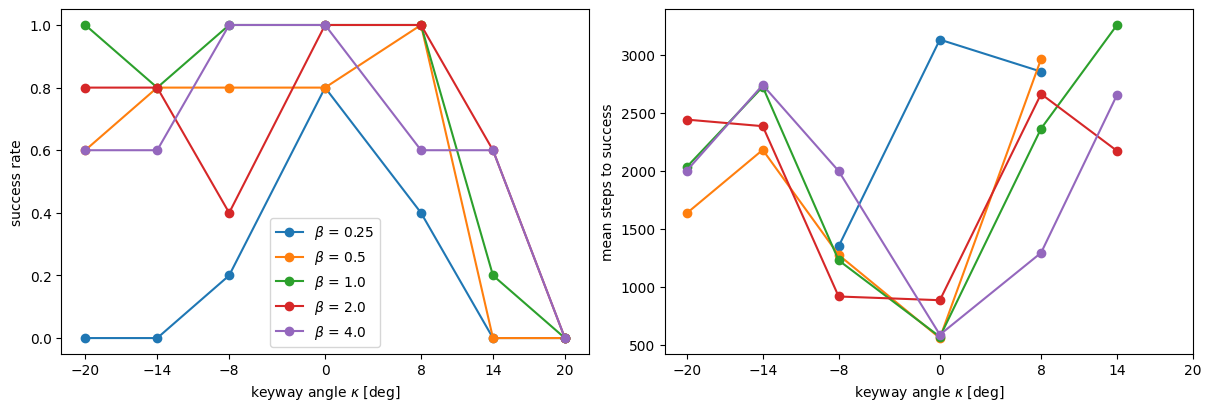

In [ ]:
fig, (ax_rate, ax_steps) = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for beta, r, n in zip(BETAS, rate, steps, strict=True):
    ax_rate.plot(KAPPAS, r, "o-", label=rf"$\beta$ = {beta}")
    ax_steps.plot(KAPPAS, n, "o-", label=rf"$\beta$ = {beta}")
ax_rate.set_ylabel("success rate")
ax_steps.set_ylabel("mean steps to success")
for ax in (ax_rate, ax_steps):
    ax.set_xlabel(r"keyway angle $\kappa$ [deg]")
    ax.set_xticks(KAPPAS)
ax_rate.legend()
plt.show()

### 7.5 Results ($K = 10$, spatial statistic of mass 1, no offset carry-forward, no step-back)

- **Port.** The mean-shift port reproduces the JavaScript prototype, also without either mechanism, run for run: 4/14 at $\beta = 1$, with identical step counts.
- **Law.** With $\varphi$ frozen, the law of Section 5 gives `ErgodicController`'s next state to within $10^{-10}$, so it is the E2T2 law.
- **E2T2 law, $\beta = 1$, seeds 3 and 4:** 11/14; with the step-back it was 10/14.
  - It fails at $\kappa = 14°$ with seed 3 and at $\kappa = 20°$ with both seeds.
  - Over 35 runs ($\beta = 1$, seeds 3 to 7) it unlocks 25 with or without the step-back. Two runs are lost and two gained.
- **Ablation.** With backward expansion off it gets 3/14: the robot stays jammed. The widening $\sigma_b$, not the
  step-back, is what makes the robot back off and re-approach after a jam.
- **$\beta$ sweep (5 seeds).**
  - The success rate is 0.71 at $\beta = 1$, 0.57 to 0.66 at 0.5, 2 and 4, and 0.20 at 0.25.
  - At $\kappa = 20°$ no run unlocks at any $\beta$ (0/25).
  - From $-20°$ to $8°$, $\beta = 1$ unlocks 24 of 25 runs.
- **The two runs of Section 6** ($\kappa = 14°$):
  - **Happy flow, seed 4.** It jams at step 116 at $-4.7°$, backs off and re-approaches, and finds the keyway at step 1765.
    It then inserts, turns, and unlocks at step 3254.
  - **Bad flow, seed 3.**
    - It jams at step 125 and finds the keyway at step 1793.
    - $\varphi$ advances into the insertion, to 0.393 (about 6.3 deep), but the robot then pulls the key back out: it is at
      $x \approx 0$ by step 2500, at the face from step 3000 on, and never turns the key.
    - $\varphi$ only moves forward, so it stays at 0.393 for the rest of the run. Its target lies inside the lock, where the
      robot can only get by first finding the keyway again.
    - This is the case the step-back corrected: a phase clock ahead of where the robot actually is.

**Why the statistic has mass 1.** With $\mathcal W$ divided by $T(\varphi)$ instead, the run was 5/14, and the law
turned away from the target after a stall. Measured on $\kappa = 0$, seed 4:

| step | $\theta$ | mass $\mathcal W_{00}$ | cos(u, statistic only) | cos(u, target only) |
|---|---|---|---|---|
| 250 | -7° | 1.07 | +1.00 | -1.00 |
| 1000 | 61° | 7.66 | +1.00 | -1.00 |
| 2000 | 94° | 16.45 | +1.00 | -1.00 |

- **The sign flips above mass 1.** The robot had covered the target slice, so $\mathcal W \approx m\,\hat{\mathcal W}$ and
  $\mathcal W - \hat{\mathcal W} \approx (m - 1)\,\hat{\mathcal W}$. Above $m = 1$ the law descended the target instead of ascending it.
- **It pressed on the face.** The least covered place was behind the face, $x > 3$, so the robot kept pushing into the face
  and slid along it to $\theta \approx 94°$.
- **Mass 1 removes this.** With mass 1, as in E2T2, the law compares shapes only.

## 8. What transfers to 6-DoF + $\varphi$

- **Metric.** `metric` becomes whitening by the cloud covariance, on the pose in the tangent space of the mean orientation.
  The cube map after it is unchanged.
- **Phase estimation when the pose does not move.** During a press or a turn against resistance, $d\ell/d\varphi \approx 0$:
  the pose hardly changes, so a projection of the pose cannot see progress. Adding force/torque to the projected
  state gives the master length along those phases.
- **Tensor trains.** With $d = 6$ the $K^d$ target density and spatial statistic need the TT form. The phase
  kernel then acts on the $\varphi$ core of a 7-D TT of the labelled cloud, so the per-step target is a contraction of one core with $w(\varphi)$.
  The spatial statistic, a 7-D TT of the memory, is contracted with $v(\varphi)$ in the same way.